In [31]:
import h5py
import numpy as np

#Open the H5 file in read mode
file_path = r"D:\Users\nina\Star_Formation_Histories\fitting\posteriors\exponential\z_2\0.03.h5"

with h5py.File(file_path, "r") as f:
    print("Top-level keys:")
    print(list(f.keys()))

Top-level keys:
['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']


In [32]:
import h5py
import numpy as np

file_path = r"D:\Users\nina\Star_Formation_Histories\fitting\posteriors\exponential\z_2\0.03.h5"

with h5py.File(file_path, "r") as f:
    print("Top-level keys:")
    print(list(f.keys()))  # Already ['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']

    # Extract 2D posterior samples
    samples2d = f["samples2d"][:]   # this is a numpy array
    print("samples2d shape:", samples2d.shape)
    print("First 5 rows:\n", samples2d[:5])

    # Extract median values
    median = f["median"][:]         # median of each parameter
    print("Median shape:", median.shape)
    print("Median values:", median)

    # Extract confidence intervals
    conf_int = f["conf_int"][:]     # shape is usually (n_params, 2)
    print("Confidence intervals:\n", conf_int)

Top-level keys:
['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']
samples2d shape: (671, 6)
First 5 rows:
 [[ 0.23239089  0.14500494  9.99139538  1.83580435  4.01931084 -2.9237023 ]
 [ 0.26031599  0.28283459 10.2147521   1.55771776  3.19276684 -3.51893125]
 [ 0.04741575  0.37356051 10.19261364  1.59617374  3.83329784 -3.43076572]
 [ 0.24641217  0.21345925 10.18756333  1.11665852  0.24268998 -3.14264517]
 [ 0.05386848  0.47788139 10.31510359  1.35982928  0.74048112 -2.59561044]]
Median shape: (6,)
Median values: [ 0.14634828  0.39134064 10.28278051  1.74838925  2.95393334 -2.2435222 ]
Confidence intervals:
 [[ 0.0491169   0.22534484 10.16309603  1.45777967  1.49661837 -2.59903764]
 [ 0.26835925  0.56935163 10.3807896   1.92565945  4.33375569 -2.07461805]]


In [33]:
params = ["Av", "age", "massformed", "metallicity", "tau", "logU"]  # example

import pandas as pd

df_samples = pd.DataFrame(samples2d, columns=params)
df_samples.head()

,Av,age,massformed,metallicity,tau,logU
0,0.232391,0.145005,9.991395,1.835804,4.019311,-2.923702
1,0.260316,0.282835,10.214752,1.557718,3.192767,-3.518931
2,0.047416,0.373561,10.192614,1.596174,3.833298,-3.430766
3,0.246412,0.213459,10.187563,1.116659,0.242690,-3.142645
4,0.053868,0.477881,10.315104,1.359829,0.740481,-2.595610


In [34]:
import h5py
import glob
import os

folder = r"D:\Users\nina\Star_Formation_Histories\fitting\posteriors\exponential\z_2"
files = sorted(glob.glob(os.path.join(folder, "*.h5")))

for fpath in files:
    with h5py.File(fpath, "r") as f:
        print(f"\nFile: {os.path.basename(fpath)}")
        print("Top-level keys:", list(f.keys()))


File: 0.0.h5
Top-level keys: ['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']

File: 0.01.h5
Top-level keys: ['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']

File: 0.01_.h5
Top-level keys: ['bound_0', 'bound_1', 'bound_10', 'bound_11', 'bound_12', 'bound_13', 'bound_14', 'bound_15', 'bound_16', 'bound_17', 'bound_18', 'bound_19', 'bound_2', 'bound_20', 'bound_21', 'bound_22', 'bound_23', 'bound_24', 'bound_25', 'bound_26', 'bound_27', 'bound_28', 'bound_3', 'bound_4', 'bound_5', 'bound_6', 'bound_7', 'bound_8', 'bound_9', 'sampler']

File: 0.02.h5
Top-level keys: ['conf_int', 'lnlike', 'lnz', 'lnz_err', 'median', 'samples2d']

File: 0.02_.h5
Top-level keys: ['bound_0', 'bound_1', 'bound_10', 'bound_11', 'bound_12', 'bound_13', 'bound_14', 'bound_15', 'bound_16', 'bound_17', 'bound_18', 'bound_19', 'bound_2', 'bound_20', 'bound_21', 'bound_22', 'bound_23', 'bound_24', 'bound_25', 'bound_26', 'bound_27', 'bound_3', 'bound_4', 'bound_5', 'bound_6', 'bound_7

In [35]:
import h5py
import glob
import os
import numpy as np
import pandas as pd

folder = r"D:\Users\nina\Star_Formation_Histories\fitting\posteriors\exponential\z_2"
files = sorted(glob.glob(os.path.join(folder, "*.h5")))

params = ["Av", "age", "massformed", "metallicity", "tau", "logU"]

data_list = []

for fpath in files:
    fname = os.path.basename(fpath)
    
    # Skip the files with "_" in the name
    if "_" in fname:
        continue
    
    age_label = fname.replace(".h5", "")
    
    with h5py.File(fpath, "r") as f:
        median = f['median'][:]       # shape (6,)
        conf_int = f['conf_int'][:]   # shape (2,6), lower and upper bounds
    
    # Store in dict
    row = {
        "age": float(age_label)
    }
    for i, p in enumerate(params):
        row[f"{p}_median"] = median[i]
        row[f"{p}_lower"] = conf_int[0, i]
        row[f"{p}_upper"] = conf_int[1, i]
    
    data_list.append(row)

# Convert to DataFrame
df = pd.DataFrame(data_list)
df = df.sort_values("age")  # sort by age

print(df)

     age  Av_median  Av_lower  Av_upper  age_median  age_lower  age_upper  \
0   0.00   0.411672  0.373813  0.458083    0.001974   0.001323   0.002918   
1   0.01   0.131088  0.049274  0.212600    0.096992   0.057921   0.159628   
2   0.02   0.142050  0.058597  0.238865    0.158778   0.093059   0.249253   
3   0.03   0.146348  0.049117  0.268359    0.391341   0.225345   0.569352   
4   0.04   0.144692  0.051137  0.251319    0.492759   0.300487   0.695870   
5   0.05   0.187670  0.085897  0.311926    0.561330   0.355912   0.825780   
6   0.06   0.290237  0.160800  0.435844    0.584944   0.355013   0.855488   
7   0.07   0.283861  0.152411  0.444181    0.581270   0.380520   0.888592   
8   0.08   0.415049  0.272079  0.548595    0.605958   0.373767   0.915908   
9   0.09   0.549163  0.404509  0.668888    0.725980   0.422660   0.982585   
10  0.10   0.538722  0.410319  0.661960    0.755019   0.424384   0.985375   
11  0.20   0.544281  0.431890  0.639333    0.876677   0.646989   1.033065   

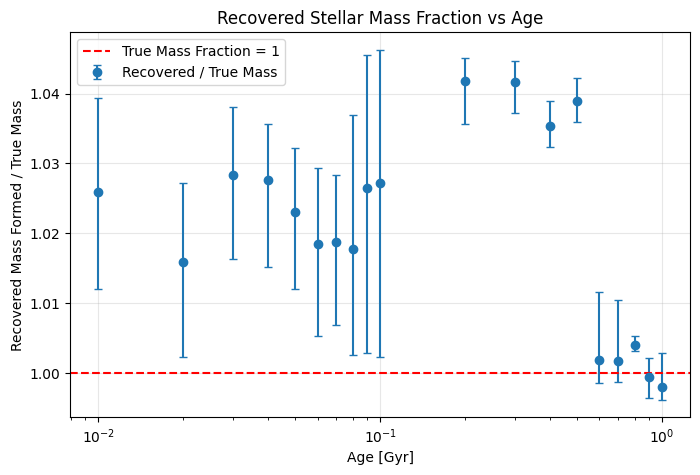

In [36]:
import matplotlib.pyplot as plt

# Assume df is the DataFrame from before

true_mass = 10.0

# Extract ages
ages = df['age']

# Extract recovered massformed median and confidence intervals
mass_median = df['massformed_median']
mass_lower = df['massformed_lower']
mass_upper = df['massformed_upper']

# Convert to fraction of true mass
mass_frac_median = mass_median / true_mass
mass_frac_lower = mass_lower / true_mass
mass_frac_upper = mass_upper / true_mass

# Compute lower and upper error bars for plotting
err_lower = mass_frac_median - mass_frac_lower
err_upper = mass_frac_upper - mass_frac_median

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(ages, mass_frac_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered / True Mass')
plt.axhline(1.0, color='r', linestyle='--', label='True Mass Fraction = 1')
plt.xlabel("Age [Gyr]")
plt.ylabel("Recovered Mass Formed / True Mass")
plt.title("Recovered Stellar Mass Fraction vs Age")
plt.xscale('log')  # Set y-axis to logarithmic scale
plt.legend()
plt.grid(alpha=0.3)
plt.show()

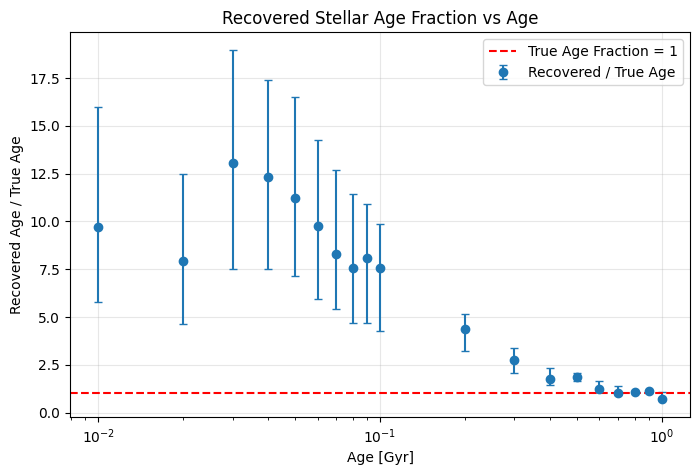

In [38]:
import matplotlib.pyplot as plt

# Assume df is the DataFrame from before

# Extract ages
ages = df['age']

# Extract recovered massformed median and confidence intervals
age_median = df['age_median']
age_lower = df['age_lower']
age_upper = df['age_upper']

# Convert to fraction of true mass
age_frac_median = age_median / ages
age_frac_lower = age_lower / ages
age_frac_upper = age_upper / ages

# Compute lower and upper error bars for plotting
err_lower = age_frac_median - age_frac_lower
err_upper = age_frac_upper - age_frac_median

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(ages, age_frac_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered / True Age')
plt.axhline(1.0, color='r', linestyle='--', label='True Age Fraction = 1')
plt.xlabel("Age [Gyr]")
plt.ylabel("Recovered Age / True Age")
plt.xscale('log')  # Set y-axis to logarithmic scale
plt.title("Recovered Stellar Age Fraction vs Age")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

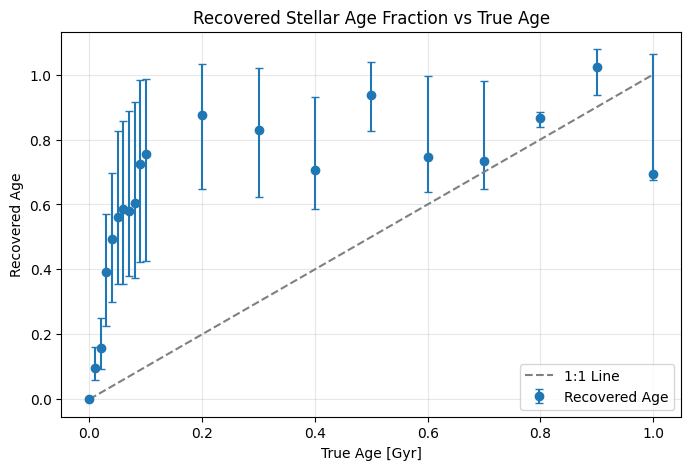

In [43]:
import matplotlib.pyplot as plt

# Assume df is the DataFrame from before

# Extract ages
ages = df['age']

# Extract recovered massformed median and confidence intervals
age_median = df['age_median']
age_lower = df['age_lower']
age_upper = df['age_upper']

# Convert to fraction of true mass
age_frac_median = age_median / ages
age_frac_lower = age_lower / ages
age_frac_upper = age_upper / ages

# Compute lower and upper error bars for plotting
err_lower = age_median - age_lower
err_upper = age_upper - age_median

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(ages, age_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered Age')
plt.xlabel("True Age [Gyr]")
plt.ylabel("Recovered Age")
plt.plot(ages, ages, linestyle='--', color='gray', label='1:1 Line')  # Add 1:1 line for reference
plt.title("Recovered Stellar Age Fraction vs True Age")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [46]:
import h5py
import glob
import os
import numpy as np
import pandas as pd

folder = r"D:\Users\nina\Star_Formation_Histories\fitting\posteriors\burst\z_2"
files = sorted(glob.glob(os.path.join(folder, "*.h5")))

params = [ "age", "massformed", "metallicity", "Av", "logU"]

data_list = []

for fpath in files:
    fname = os.path.basename(fpath)
    
    # Skip the files with "_" in the name
    if "_" in fname:
        continue
    
    age_label = fname.replace(".h5", "")
    
    with h5py.File(fpath, "r") as f:
        median = f['median'][:]       # shape (6,)
        conf_int = f['conf_int'][:]   # shape (2,6), lower and upper bounds
    
    # Store in dict
    row = {
        "age": float(age_label)
    }
    for i, p in enumerate(params):
        row[f"{p}_median"] = median[i]
        row[f"{p}_lower"] = conf_int[0, i]
        row[f"{p}_upper"] = conf_int[1, i]
    
    data_list.append(row)

# Convert to DataFrame
df = pd.DataFrame(data_list)
df = df.sort_values("age")  # sort by age

print(df)

     age  age_median  age_lower  age_upper  massformed_median  \
0   0.00    0.042770   0.037434   0.055675          11.339424   
1   0.01    0.018804   0.014592   0.021860          10.214833   
2   0.02    0.021163   0.016183   0.026143          10.032967   
3   0.03    0.031012   0.020619   0.040903          10.037652   
4   0.04    0.041280   0.026923   0.051691          10.054352   
5   0.05    0.056293   0.040369   0.068662          10.062303   
6   0.06    0.069530   0.055722   0.084463          10.040716   
7   0.07    0.068716   0.052379   0.083825          10.035939   
8   0.08    0.086186   0.071804   0.104682          10.021562   
9   0.09    0.105011   0.072615   0.128010          10.013616   
10  0.10    0.104700   0.067590   0.131825          10.012632   
11  0.20    0.217772   0.184000   0.274891          10.009834   
12  0.30    0.379098   0.310840   0.429626          10.254136   
13  0.40    0.507690   0.423128   0.596574          10.205157   
14  0.50    0.636037   0.

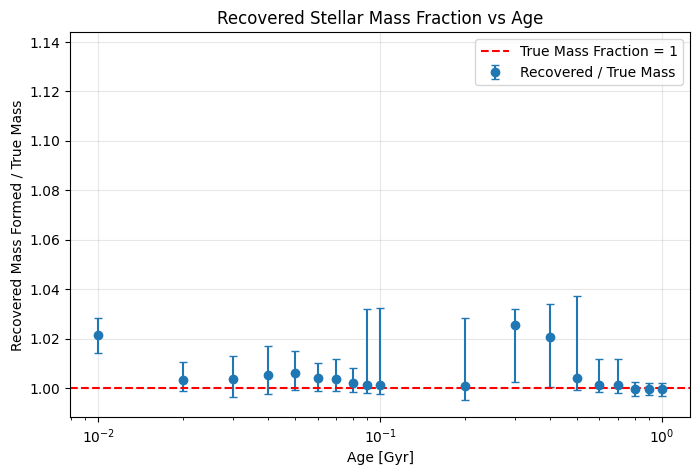

In [47]:
import matplotlib.pyplot as plt

# Assume df is the DataFrame from before

true_mass = 10.0

# Extract ages
ages = df['age']

# Extract recovered massformed median and confidence intervals
mass_median = df['massformed_median']
mass_lower = df['massformed_lower']
mass_upper = df['massformed_upper']

# Convert to fraction of true mass
mass_frac_median = mass_median / true_mass
mass_frac_lower = mass_lower / true_mass
mass_frac_upper = mass_upper / true_mass

# Compute lower and upper error bars for plotting
err_lower = mass_frac_median - mass_frac_lower
err_upper = mass_frac_upper - mass_frac_median

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(ages, mass_frac_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered / True Mass')
plt.axhline(1.0, color='r', linestyle='--', label='True Mass Fraction = 1')
plt.xlabel("Age [Gyr]")
plt.ylabel("Recovered Mass Formed / True Mass")
plt.title("Recovered Stellar Mass Fraction vs Age")
plt.xscale('log')  # Set y-axis to logarithmic scale
plt.legend()
plt.grid(alpha=0.3)
plt.show()

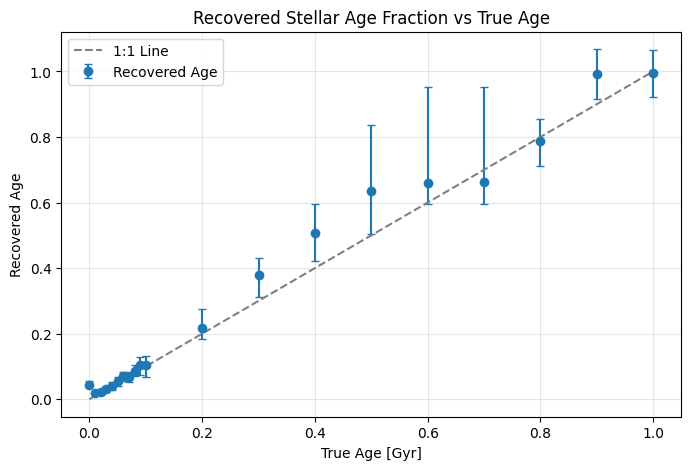

In [48]:
import matplotlib.pyplot as plt

# Assume df is the DataFrame from before

# Extract ages
ages = df['age']

# Extract recovered massformed median and confidence intervals
age_median = df['age_median']
age_lower = df['age_lower']
age_upper = df['age_upper']

# Convert to fraction of true mass
age_frac_median = age_median / ages
age_frac_lower = age_lower / ages
age_frac_upper = age_upper / ages

# Compute lower and upper error bars for plotting
err_lower = age_median - age_lower
err_upper = age_upper - age_median

# Plot
plt.figure(figsize=(8,5))
plt.errorbar(ages, age_median, yerr=[err_lower, err_upper], fmt='o', capsize=3, label='Recovered Age')
plt.xlabel("True Age [Gyr]")
plt.ylabel("Recovered Age")
plt.plot(ages, ages, linestyle='--', color='gray', label='1:1 Line')  # Add 1:1 line for reference
plt.title("Recovered Stellar Age Fraction vs True Age")
plt.legend()
plt.grid(alpha=0.3)
plt.show()